In [1]:
import pathlib

import numpy as np
import pandas as pd

In [2]:
from trait_prediction.main import PhenotypeSet, PhenotypeIndex
from trait_prediction.utils import (
    read_interpro_features,
    read_rast_features,
)


## Reading the data


In [5]:
data_folder = pathlib.Path("../data/raw/")

metabolic_phenotype_file = data_folder / "non_metabolic_phenotypes_bacdive.tsv"
non_metabolic_phenotype_file = data_folder / "non_metabolic_phenotypes_bacdive.tsv"
rast_feature_file = data_folder / "rast_features.tsv"
interpro_feature_file = data_folder / "interpro_features.tsv"

In [6]:
metabolic_phenotypeset = PhenotypeSet.read_data(str(metabolic_phenotype_file))
non_metabolic_phenotypeset = PhenotypeSet.read_data(str(non_metabolic_phenotype_file))

In [7]:
rast_features, rast_sso_dict = read_rast_features(rast_feature_file)
interpro_features, interpro_ipr_dict = read_interpro_features(interpro_feature_file)

In [8]:
grampos_index = PhenotypeIndex(name="gram_positive", category="unknown")
grampos_phenotype = non_metabolic_phenotypeset[grampos_index]
grampos_phenotype.set_feature_data(rast_features, "rast")

In [9]:
grampos_phenotype

Phenotype (name=gram_positive, category=unknown, size=3488)

## Machine learning using the RAST annotations


In [10]:
from collections import Counter

counter = Counter(grampos_phenotype.phenotype_data)
counter

Counter({0: 2229, 1: 1259})

In [11]:
low_var_features, correlated_features_dict = grampos_phenotype.filter_feature_data(
    variance_threshold=0.05, correlation_treshold=0.95
)

In [12]:
from catboost import CatBoostClassifier

In [13]:
random_state = 42

In [14]:
clf = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.1,
    random_state=random_state,
    verbose=False,
)

In [15]:
from trait_prediction.training import PhenotypePredictor

In [16]:
phenotype_predictor = PhenotypePredictor(grampos_phenotype, clf, random_state=random_state)

In [17]:
data = phenotype_predictor.split_data(test_size=0.3, stratify=True, imbalanced="auto")

Performing Undersampling...


In [18]:
phenotype_predictor.fit()

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
)

In [23]:
y_pred = phenotype_predictor.predict()

In [24]:
y_true = data["y_test"]

In [25]:
confusion_matrix(y_true, y_pred)

array([[653,  16],
       [  5, 373]], dtype=int64)

In [26]:
f1_score(y_true, y_pred, average="weighted")

0.9800033889865135

## SHAP values


In [27]:
import shap

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [28]:
explainer = shap.Explainer(clf)

In [29]:
shap_values = explainer.shap_values(data["X_train"])

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


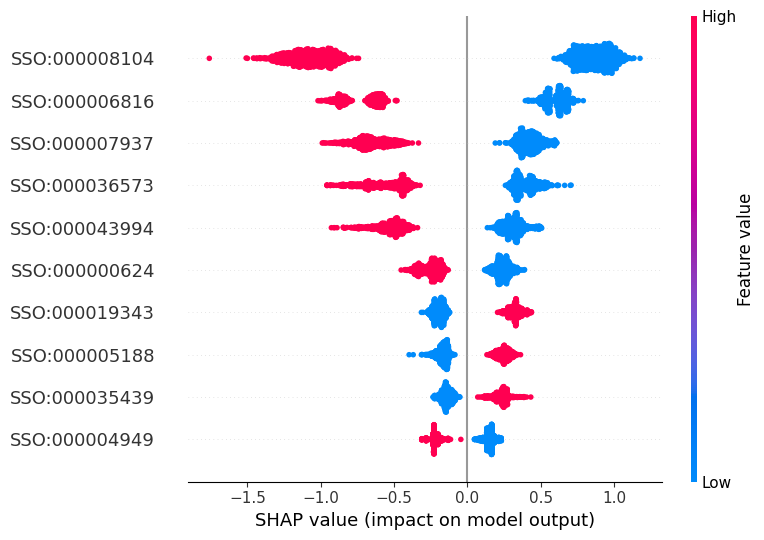

In [30]:
shap.summary_plot(shap_values, data["X_train"], max_display=10)

In [31]:
rast_sso_dict["SSO:000008104"], rast_sso_dict["SSO:000006816"], rast_sso_dict[
    "SSO:000007937"
],

('TonB-dependent receptor',
 "Pyridoxine 5'-phosphate synthase (EC 2.6.99.2)",
 "Tetraacyldisaccharide 4'-kinase (EC 2.7.1.130)")

TonB is an outer membrane protein
Tetraaacyyldisaccharide 4'-kinase is an enzyme precursor for LSP (gram neg outermembrane)